In [3]:
import numpy as np
from numpy.linalg import norm, solve, LinAlgError
import matplotlib.pyplot as plt
#from case_studies import * 

In [37]:
def solve_sphere_constrained(Q, b, Delta, tol=1e-8, max_iter=100):
    """
    Solve the quadratic minimization problem
      min (1/2 x^T Q x + b^T x)
      s.t. ||x||^2 <= Delta^2,
    using a bisection search on the Lagrange multiplier lambda.
    
    Returns:
      x_star: the computed solution,
      lambda_star: the final Lagrange multiplier,
      iter_count: number of bisection iterations,
      phi_val: final value of phi(lambda) (should be close to 0).
    """
    n = Q.shape[0]
    
    #  Compute the unconstrained minimizer: Q x + b = 0  =>  x = -Q^{-1}b.
    try:
        x_uncon = solve(Q, -b)
    except LinAlgError:
        raise ValueError("Matrix Q is singular or ill-conditioned.")

    
    # If the smallest eigenvalue of Q is positive and the unconstrained minimizer is feasible,
    # then return p(0) with lambda = 0.
    eigvals = np.linalg.eigvalsh(Q)
    if eigvals[0] > 0 and norm(x_uncon) <= Delta:
        return x_uncon, 0.0, 0, norm(x_uncon) - Delta
    
    
    # If the unconstrained solution is feasible, return it.
    #if norm(x_uncon) <= Delta:
    #    return x_uncon, 0.0, 0, norm(x_uncon) - Delta

    # Define x(lambda) = -(Q + 2 lambda I)^{-1} b.
    def x_of_lambda(lam):
        return solve(Q + 2*lam*np.eye(n), -b)
    
    # Define phi(lambda) = ||x(lambda)|| - Delta.
    def phi(lam):
        return norm(x_of_lambda(lam)) - Delta

    # Step 1: Find an interval [lambda_low, lambda_high] where phi changes sign.
    lambda_low = 0.0
    lambda_high = 1.0
    while phi(lambda_high) > 0:
        lambda_high *= 2.0
        if lambda_high > 1e10:
            raise RuntimeError("Unable to bracket the root; problem may be ill-conditioned.")

    # Step 2: Bisection loop to find lambda such that ||x(lambda)|| ~= Delta.
    iter_count = 0
    lam_star = None
    x_star = None
    while iter_count < max_iter:
        lam_mid = 0.5 * (lambda_low + lambda_high)
        x_mid = x_of_lambda(lam_mid)
        # Update bracket based on the current norm.
        if norm(x_mid) > Delta:
            lambda_low = lam_mid
        else:
            lambda_high = lam_mid

        iter_count += 1
        
        # Check stopping criterion on lambda.
        if abs(lambda_high - lambda_low) < tol:
            lam_star = lam_mid
            x_star = x_mid
            break
    else:
        # If max_iter reached without convergence, return the last iterate.
        lam_star = lam_mid
        x_star = x_mid

    return x_star, lam_star, iter_count, phi(lam_star)

#Take KKT from last week
def check_KKT(Q, b, Delta, x, lam, tol=1e-6):
    """Check the KKT conditions for the trust-region subproblem.
   The KKT conditions are:
      1) Stationarity:
            ∇f(x) + Σ_{j in I} λ_j * ∇c_j(x) + Σ_{i in E} μ_i * ∇c_i(x) = 0.
      2) Complementarity:
            For each j in I:  λ_j * c_j(x) = 0.
      3) Inequality feasibility:
            For each j in I:  c_j(x) ≤ 0.
      4) Equality feasibility:
            For each i in E:  c_i(x) = 0.
      5) Dual feasibility:
            For each j in I:  λ_j ≥ 0

    Returns a dictionary with residuals.
   """
    # Stationarity should be 0
    stationarity_resid = norm((Q + 2*lam*np.eye(Q.shape[0])).dot(x) + b)
    # Complementarity should be  0
    comp_resid = abs(lam * (norm(x)**2 - Delta**2))
    # Inequality constraint should be ≤ 0
    ineq_feas = norm(x) ** 2 - Delta ** 2 <= 0 
    # Equality feasibility should be the same condition
    equal_feas = abs(norm(x) ** 2 - Delta ** 2) <= tol
    # Dual feasibility should ensure lambda is non-negative
    dual_feas = lam >= -tol  # allow slight numerical negative drift
    
    return {
        'stationarity': stationarity_resid,
        'complementarity': comp_resid,
        'ineq_feasibility': ineq_feas,
        'equal_feasibility': equal_feas,
        'dual_feasibility': dual_feas
    }
    
def quadratic_solver(Q, b, delta, epsilon=1e-8, max_iter=100):
    """
    Solve the quadratic function with norm constraint.
    Args:
        Q (ndarray): n x n symmetric matrix.
        b (ndarray): n-dimensional vector.
        delta (float): Radius constraint.
        epsilon (float): Precision tolerance.
    Returns:
        ndarray: Optimal feasible x*.
    """
 
    # g corresponds to the vector b given as input to the problem.
    # np.linalg.solve(A, b): Solves the system of linear equations Ax=b 
    # without explicitly computing A^−1
    In = np.eye(Q.shape[0])
    def p(lambda_):
        return -np.linalg.solve(Q + lambda_ * In, b)

    xs = [p(0)]
    ls = [0]
    
    # Compute the smallest eigenvalue of Q 
    # and Check the initial conditions
    eigenvalues = np.linalg.eigvalsh(Q)
    lambda_1 = np.min(eigenvalues)
    if lambda_1 > 0 and np.linalg.norm(p(0)) <= delta:
        return np.array(xs), np.array(ls)

    # Set initial bounds for lambda
    l = max(0, -lambda_1)
    u = l + 1

    # Expand upper bound until the norm of p(u) exceeds delta
    while np.linalg.norm(p(u)) > delta:
        l = u
        u *= 2

    # Binary search to find the optimal lambda
    while max_iter >= len(xs):
        lambda_prime = 0.5 * (l + u)
        p_prime = p(lambda_prime)
        xs.append(p_prime)
        ls.append(lambda_prime)
        norm_p_prime = np.linalg.norm(p_prime)

        if norm_p_prime < delta and abs(norm_p_prime - delta) < epsilon:
            break

        if norm_p_prime > delta:
            l = lambda_prime
        else:
            u = lambda_prime
    
    return np.array(xs), np.array(ls)

In [38]:
# -------------------------------
# Construct various test instances
# -------------------------------
def run_tests():
    # n_runs = 5
    # dims = 2
    # alpha = 1000.0
    # Delta = 1.0  # Trust-region radius.
    
    # unconstrained_runs = 0
    # active_runs = 0
    # iterations_list = []
    # kkt_stationarity_list = []
    epsilon=1e-8
    tests = []
    
    # for i in range(n_runs):
    #     # Random starting point x_k from [2,25]^dims.
    #     x_k = np.random.uniform(2, 25, dims)
    #     # For f1, the quadratic model at x_k:
    #     Q = Hf1(x_k, alpha)
    #     b = df1(x_k, alpha)
    #     # The unconstrained minimizer is p = -x_k.
    #     p_uncon = -x_k
    #     norm_uncon = norm(p_uncon)
    x_0 = 10 * np.random.randn(2)
    #Q0 = Hf1(x_0)
    #b0 = df1(x_0)
    #Delta0 = 0.1
    #tests.append(('Random', Q0, b0, Delta0))
    #print("Optimum =", x_opt(f1, 2))
    #print("x_0 =",x_0)
    #print("b =",b0)
    #print("Q =",Q0)
    
    
    
    # Test Case 1: Unconstrained solution feasible
    # Q positive definite, unconstrained minimizer inside the ball.
    Q1 = np.array([[2.0, 0.0],
                   [0.0, 2.0]])
    b1 = np.array([-1.0, -1.0])
    Delta1 = 1.5  # norm(unconstrained) ~0.707, so feasible.
    tests.append(('Feasible Unconstrained', Q1, b1, Delta1))
    
    # Test Case 2: Unconstrained solution infeasible (boundary active)
    # Q positive definite, unconstrained minimizer outside the ball.
    Q2 = np.array([[2.0, 0.0],
                   [0.0, 2.0]])
    b2 = np.array([-2.0, -2.0])
    Delta2 = 1.0  # unconstrained minimizer would be [1,1] with norm ~1.414 > 1.
    tests.append(('Active Constraint', Q2, b2, Delta2))
    
    # Test Case 3: Indefinite Q (simple example)
    Q3 = np.array([[1.0, 0.0],
                   [0.0, -1.0]])
    b3 = np.array([0.5, 0.5])
    Delta3 = 1.0
    tests.append(('Indefinite Q', Q3, b3, Delta3))
    
    # Test Case 4: Negative definite Q
    Q4 = -np.array([[1.0, 0.0],
                    [0.0, 1.0]])
    b4 = np.array([1.0, 1.0])
    Delta4 = 0.8  # unconstrained minimizer is [1,1] (norm ~1.414), so constraint active.
    tests.append(('Negative Definite Q', Q4, b4, Delta4))
    
    print("Running Test Cases:\n")
    for name, Q, b, Delta in tests:
        print(f"Test: {name}")
        # try:
        #     x_star, lam_star, iters, phi_val = solve_sphere_constrained(Q, b, Delta, tol=1e-8)
        # except Exception as e:
        #     print("  Error:", e)
        #     continue

        # kkt = check_KKT(Q, b, Delta, x_star, lam_star)
        # print("  x* =", x_star)
        # print("  lambda* =", lam_star)
        # print("  ||x*|| =", norm(x_star))
        # print("  Iterations =", iters)
        # print("  phi(lambda*) =", phi_val)
        # print("  KKT residuals:")
        
        # for key, val in kkt.items():
        #     print(f"    {key}: {val}")
        
        xs, ls = quadratic_solver(Q, b, Delta, epsilon=epsilon)
        print("x* =", xs[-1])    
        print("lambda* =", ls[-1])
        print("Iterations =", len(xs)-1)
        kkt = check_KKT(Q, b, Delta, xs[-1], ls[-1], tol=epsilon)
        for key, val in kkt.items():
            print(f"    {key}: {val}")

        print("-"*50)
        
# Run all tests
run_tests()

Running Test Cases:

Test: Feasible Unconstrained
x* = [0.5 0.5]
lambda* = 0
Iterations = 0
    stationarity: 0.0
    complementarity: 0.0
    ineq_feasibility: True
    equal_feasibility: False
    dual_feasibility: True
--------------------------------------------------
Test: Active Constraint
x* = [0.70710678 0.70710678]
lambda* = 0.8284271359443665
Iterations = 24
    stationarity: 0.8284271326644963
    complementarity: 6.5597399380190626e-09
    ineq_feasibility: True
    equal_feasibility: True
    dual_feasibility: True
--------------------------------------------------
Test: Indefinite Q
x* = [-0.19918541 -0.97996181]
lambda* = 1.510223962366581
Iterations = 27
    stationarity: 1.5102239527801269
    complementarity: 1.9172908120091338e-08
    ineq_feasibility: True
    equal_feasibility: False
    dual_feasibility: True
--------------------------------------------------
Test: Negative Definite Q
x* = [-0.56568542 -0.56568542]
lambda* = 2.7677669674158096
Iterations = 27
    

In [39]:
import numpy as np
import pandas as pd

def run_tests():
    epsilon = 1e-10
    tests = []
    
    # Test Case 1: Unconstrained solution feasible
    Q1 = np.array([[2.0, 0.0],
                   [0.0, 2.0]])
    b1 = np.array([-1.0, -1.0])
    Delta1 = 1.5  # The unconstrained minimizer is inside the trust-region.
    tests.append(('Feasible Unconstrained', Q1, b1, Delta1))
    
    # Test Case 2: Unconstrained solution infeasible (boundary active)
    Q2 = np.array([[2.0, 0.0],
                   [0.0, 2.0]])
    b2 = np.array([-2.0, -2.0])
    Delta2 = 1.0  # The unconstrained minimizer lies outside the trust-region.
    tests.append(('Active Constraint', Q2, b2, Delta2))
    
    # Test Case 3: Indefinite Q (simple example)
    Q3 = np.array([[1.0, 0.0],
                   [0.0, -1.0]])
    b3 = np.array([0.5, 0.5])
    Delta3 = 1.0
    tests.append(('Indefinite Q', Q3, b3, Delta3))
    
    # Test Case 4: Negative definite Q
    Q4 = -np.array([[1.0, 0.0],
                    [0.0, 1.0]])
    b4 = np.array([1.0, 1.0])
    Delta4 = 0.8  # The unconstrained minimizer is outside the trust-region.
    tests.append(('Negative Definite Q', Q4, b4, Delta4))
    
    print("Running Test Cases:\n")
    
    # Loop over each test case
    for name, Q, b, Delta in tests:
        results = []
        for run in range(5):
            # Run the solver (assuming quadratic_solver and check_KKT are defined)
            xs, ls = quadratic_solver(Q, b, Delta, epsilon=epsilon)
            final_x = xs[-1]
            final_lambda = ls[-1]
            iterations = len(xs) - 1
            kkt = check_KKT(Q, b, Delta, final_x, final_lambda, tol=epsilon)
            
            # Convert KKT values to booleans if necessary (using threshold 0.5)
            kkt_bool = {}
            for key, val in kkt.items():
                # Check if the value is numeric (0.0 or 1.0) and convert to bool.
                if isinstance(val, (int, float)):
                    kkt_bool[key] = True if val >= 0.5 else False
                else:
                    kkt_bool[key] = val
            
            results.append({
                "Run": run + 1,
                "x*": final_x, 
                "lambda*": final_lambda,
                "Iterations": iterations,
                "ineq_feasibility": kkt_bool.get("ineq_feasibility", None),
                "equal_feasibility": kkt_bool.get("equal_feasibility", None),
                "dual_feasibility": kkt_bool.get("dual_feasibility", None)
            })
        
        # Create a DataFrame to tabulate the results
        df = pd.DataFrame(results)
        print(f"Test: {name}")
        print(df.to_string(index=False))
        print("-" * 50)

# Run all tests
run_tests()


Running Test Cases:

Test: Feasible Unconstrained
 Run         x*  lambda*  Iterations  ineq_feasibility  equal_feasibility  dual_feasibility
   1 [0.5, 0.5]        0           0              True              False              True
   2 [0.5, 0.5]        0           0              True              False              True
   3 [0.5, 0.5]        0           0              True              False              True
   4 [0.5, 0.5]        0           0              True              False              True
   5 [0.5, 0.5]        0           0              True              False              True
--------------------------------------------------
Test: Active Constraint
 Run                                       x*  lambda*  Iterations  ineq_feasibility  equal_feasibility  dual_feasibility
   1 [0.7071067811809711, 0.7071067811809711] 0.828427          28              True               True              True
   2 [0.7071067811809711, 0.7071067811809711] 0.828427          28             

In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import solve, norm, LinAlgError

# Test combinations of Q, b, Delta, and epsilon

# --- Solver Functions ---

def quadratic_solver(Q, b, delta, epsilon=1e-8, max_iter=100):
    """
    Solve the quadratic function:
         f(x) = 0.5*x^T Q x + b^T x,
    subject to ||x|| <= delta.
    
    This version uses a binary search on lambda to find the optimal solution.
    
    Returns:
      xs: A history (list) of computed solutions.
      ls: A history (list) of the corresponding lambda values.
    """
    In = np.eye(Q.shape[0])
    def p(lambda_):
        return -np.linalg.solve(Q + lambda_ * In, b)

    xs = [p(0)]
    ls = [0]
    
    eigenvalues = np.linalg.eigvalsh(Q)
    lambda_1 = np.min(eigenvalues)
    if lambda_1 > 0 and np.linalg.norm(p(0)) <= delta:
        return np.array(xs), np.array(ls)

    l = max(0, -lambda_1)
    u = l + 1

    while np.linalg.norm(p(u)) > delta:
        l = u
        u *= 2

    while len(xs) < max_iter:
        lambda_prime = 0.5 * (l + u)
        p_prime = p(lambda_prime)
        xs.append(p_prime)
        ls.append(lambda_prime)
        norm_p_prime = np.linalg.norm(p_prime)
        if norm_p_prime < delta and abs(norm_p_prime - delta) < epsilon:
            break
        if norm_p_prime > delta:
            l = lambda_prime
        else:
            u = lambda_prime
    
    return np.array(xs), np.array(ls)

def check_KKT(Q, b, Delta, x, lam, tol=1e-6):
    """
    Check the KKT conditions for the trust-region (quadratic) subproblem:
    
      1) Stationarity: (Q + 2*lam I)x + b = 0.
      2) Complementarity: lam * (||x||^2 - Delta^2) = 0.
      3) Inequality feasibility: ||x||^2 - Delta^2 <= 0.
      4) Equality feasibility: (here equivalent to the above constraint being active within tol).
      5) Dual feasibility: lam >= 0.
    
    Returns a dictionary with the residuals.
    """
    stationarity_resid = norm((Q + 2*lam*np.eye(Q.shape[0])).dot(x) + b)
    comp_resid = abs(lam * (norm(x)**2 - Delta**2))
    ineq_feas = (norm(x)**2 - Delta**2) <= tol
    equal_feas = abs(norm(x)**2 - Delta**2) <= tol
    dual_feas = lam >= -tol  # allowing a small numerical drift
    
    return {
        'stationarity': stationarity_resid,
        'complementarity': comp_resid,
        'ineq_feasibility': ineq_feas,
        'equal_feasibility': equal_feas,
        'dual_feasibility': dual_feas
    }

# --- Testing Code ---

def run_tests():
    # Define the Q matrices from your test cases:
    tests = []
    tests.append(('Feasible Unconstrained', np.array([[2.0, 0.0],
                                                       [0.0, 2.0]])))
    tests.append(('Active Constraint', np.array([[2.0, 0.0],
                                                  [0.0, 2.0]])))
    tests.append(('Indefinite Q', np.array([[1.0, 0.0],
                                             [0.0, -1.0]])))
    tests.append(('Negative Definite Q', -np.array([[1.0, 0.0],
                                                     [0.0, 1.0]])))
    
    # Parameter sets (overriding b and Delta from test cases):
    b_list = [np.array([0.5, 0.5]), np.array([1.0, 1.0]), np.array([-1.0, -1.0])]
    Delta_list = [0.8, 1.0, 1.5]
    epsilon_list = [1e-6, 1e-10]
    
    results = []
    
    # Loop over every test case and every combination of b, Delta, and epsilon.
    for test_name, Q in tests:
        for Delta in Delta_list:
            for b in b_list:
                for epsilon in epsilon_list:
                    xs, ls = quadratic_solver(Q, b, Delta, epsilon=epsilon)
                    final_x = xs[-1]
                    final_lambda = ls[-1]
                    iterations = len(xs) - 1
                    kkt = check_KKT(Q, b, Delta, final_x, final_lambda, tol=epsilon)
                    
                    results.append({
                        "Test": test_name,
                        "Delta": Delta,
                        "b": str(b),
                        "epsilon": epsilon,
                        "x*": final_x,
                        "lambda*": final_lambda,
                        "Iterations": iterations,
                        "KKT": kkt
                    })
    
    df = pd.DataFrame(results)
    print(df.to_string(index=False))


# Run tests for every combination using the Q's from the given test cases.
run_tests()


                  Test  Delta         b      epsilon                                          x*  lambda*  Iterations                                                                                                                                                             KKT
Feasible Unconstrained    0.8 [0.5 0.5] 1.000000e-06                              [-0.25, -0.25] 0.000000           0                                   {'stationarity': 0.0, 'complementarity': 0.0, 'ineq_feasibility': True, 'equal_feasibility': False, 'dual_feasibility': True}
Feasible Unconstrained    0.8 [0.5 0.5] 1.000000e-10                              [-0.25, -0.25] 0.000000           0                                   {'stationarity': 0.0, 'complementarity': 0.0, 'ineq_feasibility': True, 'equal_feasibility': False, 'dual_feasibility': True}
Feasible Unconstrained    0.8   [1. 1.] 1.000000e-06                                [-0.5, -0.5] 0.000000           0                                   {'stationarity

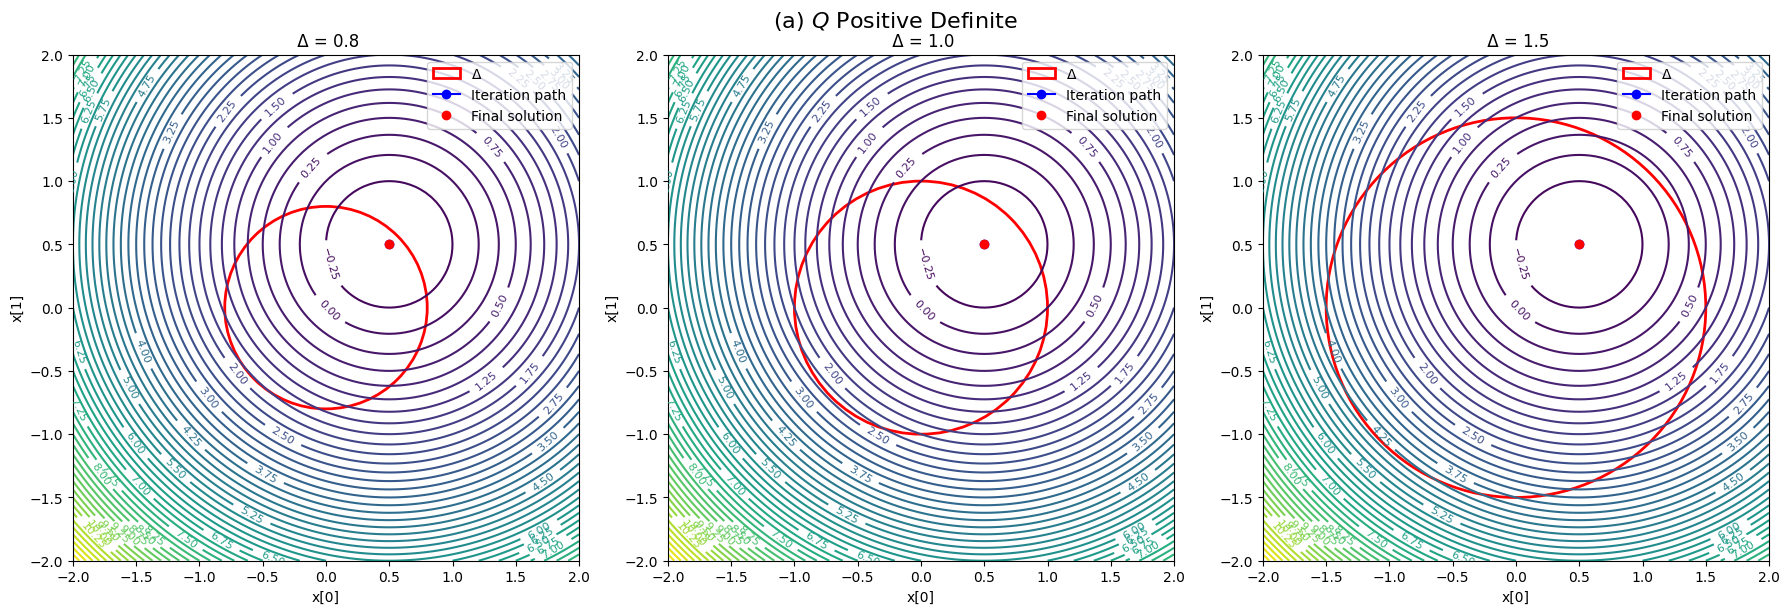

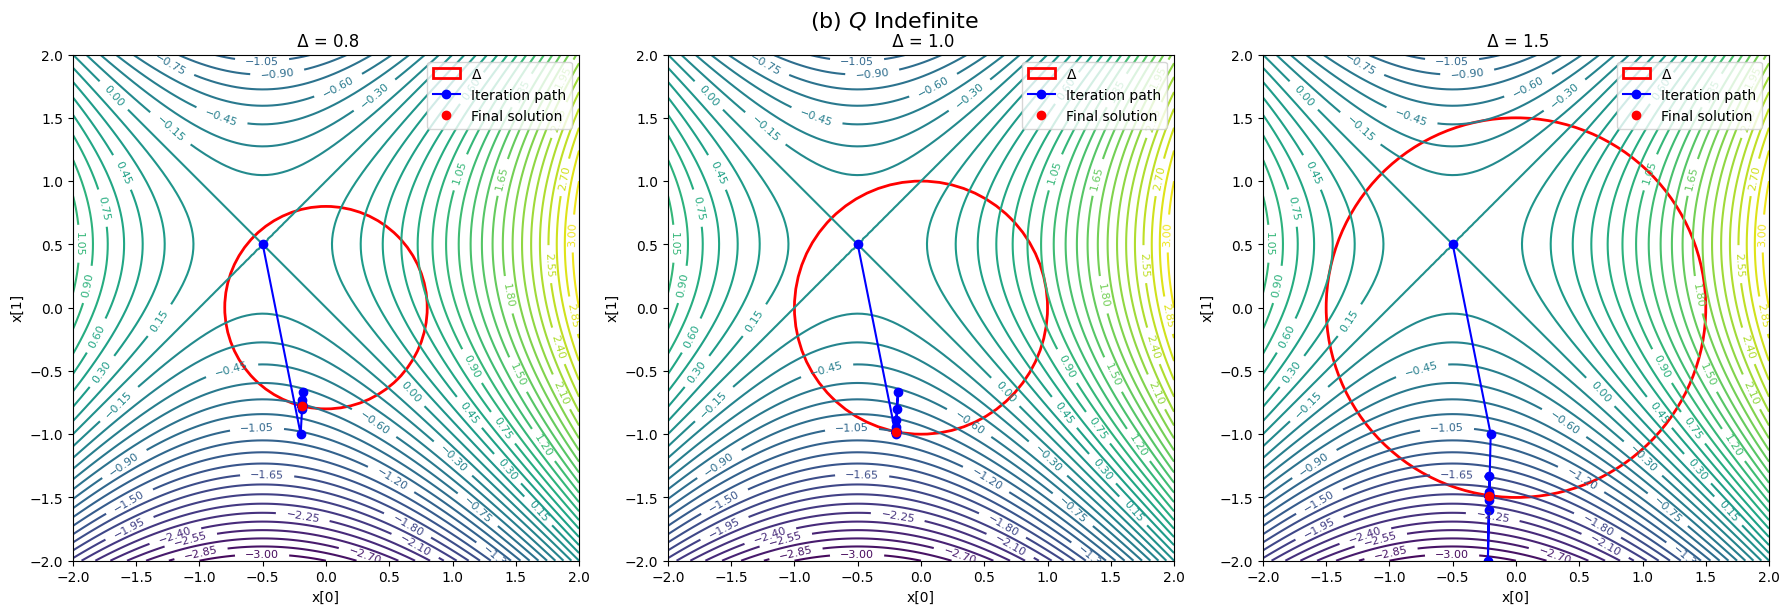

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import solve, norm, LinAlgError

#  Separete setup for plotting 2 cases of Q with 3 different deltas

def quadratic_solver(Q, b, delta, epsilon=1e-8, max_iter=100):
    """
    Solve the quadratic function:
         f(x) = 0.5*x^T Q x + b^T x,
    subject to ||x|| <= delta.
    
    Returns:
      xs: A history (list) of computed solutions (each is a 2D vector).
      ls: A history (list) of the corresponding lambda values.
    """
    In = np.eye(Q.shape[0])
    def p(lambda_):
        return -np.linalg.solve(Q + lambda_ * In, b)

    xs = [p(0)]
    ls = [0]
    
    eigenvalues = np.linalg.eigvalsh(Q)
    lambda_1 = np.min(eigenvalues)
    if lambda_1 > 0 and np.linalg.norm(p(0)) <= delta:
        return np.array(xs), np.array(ls)

    l = max(0, -lambda_1)
    u = l + 1

    while np.linalg.norm(p(u)) > delta:
        l = u
        u *= 2

    while len(xs) < max_iter:
        lambda_prime = 0.5 * (l + u)
        p_prime = p(lambda_prime)
        xs.append(p_prime)
        ls.append(lambda_prime)
        norm_p_prime = np.linalg.norm(p_prime)
        if norm_p_prime < delta and abs(norm_p_prime - delta) < epsilon:
            break
        if norm_p_prime > delta:
            l = lambda_prime
        else:
            u = lambda_prime
    
    return np.array(xs), np.array(ls)

def plot_quadratic_2D(ax, Q, b, Delta, xs, title="Quadratic Problem"):
    """
    Plot the 2D contours of f(x,y)=0.5*[x,y]Q[x,y]^T + b^T[x,y],
    plus the trust-region boundary (circle of radius Delta),
    plus the iteration path returned by the solver, on the provided axis.
    
    Parameters:
      ax: matplotlib axis to plot on.
      Q (2x2 np.array): Hessian of the quadratic function.
      b (2d np.array):  Linear term.
      Delta (float):    Trust-region radius.
      xs (N x 2 array): Sequence of solutions from the solver.
      title (str):      Title for the subplot.
    """
    # 1. Prepare a mesh grid
    grid_min, grid_max = -2.0, 2.0
    grid_points = 100
    x_vals = np.linspace(grid_min, grid_max, grid_points)
    y_vals = np.linspace(grid_min, grid_max, grid_points)
    X, Y = np.meshgrid(x_vals, y_vals)
    
    # 2. Evaluate f on the grid: f(x,y)=0.5*[x,y] Q [x,y]^T + b^T[x,y]
    F = np.zeros_like(X)
    for i in range(grid_points):
        for j in range(grid_points):
            xy = np.array([X[i,j], Y[i,j]])
            F[i,j] = 0.5 * xy @ (Q @ xy) + b @ xy

    # 3. Plot the contour on the provided axis
    cs = ax.contour(X, Y, F, levels=50, cmap='viridis')
    ax.clabel(cs, inline=1, fontsize=8)
    
    # 4. Plot the trust-region boundary: circle of radius Delta
    circle = plt.Circle((0, 0), Delta, color='red', fill=False, linewidth=2, label=r"$\Delta$")
    ax.add_patch(circle)
    
    # 5. Plot the iteration path from xs (assumed shape (num_iters, 2))
    ax.plot(xs[:,0], xs[:,1], marker='o', color='blue', label="Iteration path")
    # Mark final solution with a distinct marker
    ax.plot(xs[-1,0], xs[-1,1], 'ro', label="Final solution")
    
    # 6. Visual settings
    ax.set_title(title)
    ax.set_xlabel("x[0]")
    ax.set_ylabel("x[1]")
    ax.set_xlim([grid_min, grid_max])
    ax.set_ylim([grid_min, grid_max])
    ax.set_aspect('equal', 'box')
    ax.legend()

def demo_plots():
    # Define test cases: here we consider two test cases.
    test_cases = [
        {
            "Q": np.array([[2.0, 0.0], [0.0, 2.0]]),  # Positive definite Q
            "b": np.array([-1.0, -1.0]),
            "title": "(a) $Q$ Positive Definite"
        },
        {
            "Q": np.array([[1.0, 0.0], [0.0, -1.0]]),  # Indefinite Q
            "b": np.array([0.5, 0.5]),
            "title": "(b) $Q$ Indefinite"
        }
    ]
    
    # Define different trust-region radii (Delta values)
    delta_values = [0.8, 1.0, 1.5]
    epsilon = 1e-8  # Stopping precision
    
    # For each test case, create one row of 3 subplots (one per Delta)
    for case in test_cases:
        Q = case["Q"]
        b = case["b"]
        base_title = case["title"]
        
        # Create a row of subplots (1 row, 3 columns)
        fig, axes = plt.subplots(1, len(delta_values), figsize=(18,6))
        
        for idx, Delta in enumerate(delta_values):
            xs, ls = quadratic_solver(Q, b, Delta, epsilon=epsilon)
            title = f" Δ = {Delta}"
            plot_quadratic_2D(axes[idx], Q, b, Delta, xs, title=title)
        
        fig.suptitle(base_title, fontsize=16)
        plt.tight_layout()
        plt.show()

# Call the demo_plots function to produce the block of 3 plots in a row per test case.
demo_plots()


In [ ]:
import numpy as np
import pandas as pd
from numpy.linalg import solve, norm, LinAlgError

def solve_sphere_constrained(Q, b, Delta, tol=1e-8, max_iter=100):
    """
    Solve the quadratic minimization problem:
         min (1/2 x^T Q x + b^T x)
         s.t. ||x||^2 <= Delta^2
    This function is tailored for quadratic functions.
    
    It first computes the unconstrained minimizer:
         x_uncon = -Q^{-1}b
    and if x_uncon is feasible (i.e. within the sphere) and Q is positive definite,
    it returns x_uncon with lambda = 0.
    Otherwise, it performs a bisection on the Lagrange multiplier lambda
    to find the optimal solution on the boundary.
    
    Returns:
      x_star: the computed solution,
      lambda_star: the final Lagrange multiplier,
      iter_count: number of bisection iterations,
      phi_val: final value of phi(lambda) (should be near 0).
    """
    n = Q.shape[0]
    
    # Compute the unconstrained minimizer: x_uncon = -Q^{-1}b.
    try:
        x_uncon = solve(Q, -b)
    except LinAlgError:
        raise ValueError("Matrix Q is singular or ill-conditioned.")
    
    # Explicit eigenvalue check: if Q is positive definite and x_uncon is feasible,
    # then x_uncon is optimal.
    eigvals = np.linalg.eigvalsh(Q)
    if eigvals[0] > 0 and norm(x_uncon) <= Delta:
        return x_uncon, 0.0, 0, norm(x_uncon) - Delta
    
    # Define x(lambda) = -(Q + 2*lambda I)^{-1} b.
    def x_of_lambda(lam):
        return solve(Q + 2*lam*np.eye(n), -b)
    
    # Define phi(lambda) = ||x(lambda)|| - Delta.
    def phi(lam):
        return norm(x_of_lambda(lam)) - Delta

    # Find a bracket [lambda_low, lambda_high] where phi changes sign.
    lambda_low = 0.0
    lambda_high = 1.0
    while phi(lambda_high) > 0:
        lambda_high *= 2.0
        if lambda_high > 1e10:
            raise RuntimeError("Unable to bracket the root; problem may be ill-conditioned.")

    # Bisection loop to find lambda such that ||x(lambda)|| ~= Delta.
    iter_count = 0
    lam_star = None
    x_star = None
    while iter_count < max_iter:
        lam_mid = 0.5 * (lambda_low + lambda_high)
        x_mid = x_of_lambda(lam_mid)
        if norm(x_mid) > Delta:
            lambda_low = lam_mid
        else:
            lambda_high = lam_mid
        iter_count += 1
        if abs(lambda_high - lambda_low) < tol:
            lam_star = lam_mid
            x_star = x_mid
            break
    else:
        lam_star = lam_mid
        x_star = x_mid

    return x_star, lam_star, iter_count, phi(lam_star)

def check_KKT(Q, b, Delta, x, lam, tol=1e-6):
    """
    Check the KKT conditions for the trust-region (quadratic) subproblem:
    
      1) Stationarity: (Q + 2*lam I)x + b = 0.
      2) Complementarity: lam * (||x||^2 - Delta^2) = 0.
      3) Inequality feasibility: ||x||^2 - Delta^2 <= 0.
      4) Equality feasibility: For this problem, it is equivalent to the inequality constraint being active (if needed).
      5) Dual feasibility: lam >= 0.
    
    Returns a dictionary with residuals for each condition.
    """
    stationarity_resid = norm((Q + 2*lam*np.eye(Q.shape[0])).dot(x) + b)
    comp_resid = abs(lam * (norm(x)**2 - Delta**2))
    ineq_feas = (norm(x)**2 - Delta**2) <= tol
    equal_feas = abs(norm(x)**2 - Delta**2) <= tol
    dual_feas = lam >= -tol  # Allowing a tiny negative drift.
    
    return {
        'stationarity': stationarity_resid,
        'complementarity': comp_resid,
        'ineq_feasibility': ineq_feas,
        'equal_feasibility': equal_feas,
        'dual_feasibility': dual_feas
    }

def quadratic_solver(Q, b, delta, epsilon=1e-8, max_iter=100):
    """
    Solve the quadratic function:
         f(x)=0.5*x^T Q x + b^T x,
    subject to ||x|| <= delta.
    
    This version uses a binary search on lambda (with a slightly different formulation)
    to find the optimal solution.
    
    Returns:
      xs: A history of computed solutions (each row is an x).
      ls: A history of the corresponding lambda values.
    """
    In = np.eye(Q.shape[0])
    def p(lambda_):
        return -np.linalg.solve(Q + lambda_ * In, b)

    xs = [p(0)]
    ls = [0]
    
    eigenvalues = np.linalg.eigvalsh(Q)
    lambda_1 = np.min(eigenvalues)
    if lambda_1 > 0 and np.linalg.norm(p(0)) <= delta:
        return np.array(xs), np.array(ls)

    l = max(0, -lambda_1)
    u = l + 1

    while np.linalg.norm(p(u)) > delta:
        l = u
        u *= 2

    while max_iter >= len(xs):
        lambda_prime = 0.5 * (l + u)
        p_prime = p(lambda_prime)
        xs.append(p_prime)
        ls.append(lambda_prime)
        norm_p_prime = np.linalg.norm(p_prime)
        if norm_p_prime < delta and abs(norm_p_prime - delta) < epsilon:
            break
        if norm_p_prime > delta:
            l = lambda_prime
        else:
            u = lambda_prime
    
    return np.array(xs), np.array(ls)

def run_tests():
    """
    Run a series of tests on quadratic functions with sphere constraints.
    This demonstrates that the solvers run on quadratic functions.
    """
    epsilon = 1e-10
    tests = []
    
    # Test Case 1: Unconstrained solution is feasible.
    Q1 = np.array([[2.0, 0.0],
                   [0.0, 2.0]])
    b1 = np.array([-1.0, -1.0])
    Delta1 = 1.5  # Unconstrained minimizer is inside the sphere.
    tests.append(('Feasible Unconstrained', Q1, b1, Delta1))
    
    # Test Case 2: Unconstrained solution infeasible (active boundary constraint).
    Q2 = np.array([[2.0, 0.0],
                   [0.0, 2.0]])
    b2 = np.array([-2.0, -2.0])
    Delta2 = 1.0  # Unconstrained minimizer is outside the sphere.
    tests.append(('Active Constraint', Q2, b2, Delta2))
    
    # Test Case 3: Indefinite Q (simple example).
    Q3 = np.array([[1.0, 0.0],
                   [0.0, -1.0]])
    b3 = np.array([0.5, 0.5])
    Delta3 = 1.0
    tests.append(('Indefinite Q', Q3, b3, Delta3))
    
    # Test Case 4: Negative definite Q.
    Q4 = -np.array([[1.0, 0.0],
                    [0.0, 1.0]])
    b4 = np.array([1.0, 1.0])
    Delta4 = 0.8  # Unconstrained minimizer is outside the sphere.
    tests.append(('Negative Definite Q', Q4, b4, Delta4))
    
    print("Running Test Cases:\n")
    for name, Q, b, Delta in tests:
        results = []
        for run in range(5):
            xs, ls = quadratic_solver(Q, b, Delta, epsilon=epsilon)
            final_x = xs[-1]
            final_lambda = ls[-1]
            iterations = len(xs) - 1
            kkt = check_KKT(Q, b, Delta, final_x, final_lambda, tol=epsilon)
            
            # For clarity, convert some KKT results to booleans.
            kkt_bool = {}
            for key, val in kkt.items():
                if isinstance(val, (int, float)):
                    kkt_bool[key] = (val < 1e-6)
                else:
                    kkt_bool[key] = val
            
            results.append({
                "Run": run + 1,
                "x*": final_x, 
                "lambda*": final_lambda,
                "Iterations": iterations,
                "Inequality Feasibility": kkt_bool.get("ineq_feasibility", None),
                "Equality Feasibility": kkt_bool.get("equal_feasibility", None),
                "Dual Feasibility": kkt_bool.get("dual_feasibility", None)
            })
        
        df = pd.DataFrame(results)
        print(f"Test: {name}")
        print(df.to_string(index=False))
        print("-" * 50)

# Run the tests to see the quadratic solver in action.
run_tests()


In [552]:
# ----- Example 1: Direct test on f1 (Ellipsoid function) -----
def test_f1():
    # Choose a dimension and a point (for f1, the optimal is at 0 but we use a nonzero x_k)
    n = 5
    x_k = np.random.randn(n)  # arbitrary point
    Delta = 1.0  # trust-region radius
    
    # For f1(x) = sum(w*x^2) with w = alpha^(linspace(0,1,n))
    alpha = 1000.0
    # For a quadratic function, the model is exact.
    # Compute Hessian and gradient at x_k:
    Q = Hf1(x_k, alpha=alpha)   # Note: Hf1 returns 2*diag(w)
    b = df1(x_k, alpha=alpha)
    
    # Solve the sphere-constrained quadratic subproblem:
    p_star, lam_star, iters, phi_val = solve_sphere_constrained(Q, b, Delta, tol=1e-8)
    
    print("Test f1 (Ellipsoid Function):")
    print("x_k =", x_k)
    print("Computed step p* =", p_star)
    print("Lagrange multiplier =", lam_star)
    print("Iterations =", iters)
    print("||p*|| =", np.linalg.norm(p_star))
    print("phi(lambda*) =", phi_val)
    
    # Check KKT conditions:
    kkt = check_KKT(Q, b, Delta, p_star, lam_star)
    print("KKT residuals:")
    for key, val in kkt.items():
        print(f"  {key}: {val}")
    print("-"*50)


# Run the tests:
# test_f1()

In [553]:
# # ----- Example 2: Trust-region step for a non-quadratic function -----
# def test_trust_region(f, df, Hf, fname, dims, Delta):
#     # Let x_k be an arbitrary starting point. For demonstration, we take a random point.
#     x_k = np.random.randn(dims)
    
#     # Compute the quadratic model's data at x_k:
#     g = df(x_k)
#     H = Hf(x_k)
    
#     # Our subproblem becomes: minimize m(p) = g^T p + 0.5 p^T H p, subject to ||p|| <= Delta.
#     p_star, lam_star, iters, phi_val = solve_sphere_constrained(H, g, Delta, tol=1e-8)
    
#     print(f"Trust-Region Test for {fname}:")
#     print("x_k =", x_k)
#     print("Computed step p* =", p_star)
#     print("Lagrange multiplier =", lam_star)
#     print("Iterations =", iters)
#     print("||p*|| =", np.linalg.norm(p_star))
#     print("phi(lambda*) =", phi_val)
    
#     # KKT check for the quadratic model subproblem:
#     kkt = check_KKT(H, g, Delta, p_star, lam_star)
#     print("KKT residuals for the model subproblem:")
#     for key, val in kkt.items():
#         print(f"  {key}: {val}")
#     print("-"*50)
    
#     # Optionally, compare the model reduction:
#     model_reduction = g.dot(p_star) + 0.5 * p_star.dot(H.dot(p_star))
#     print("Model reduction =", model_reduction)
#     print("="*50)
    
# # You can similarly run trust-region tests on f2, f3, f4, f5.
# # For example, testing on the Rosenbrock function (f2):
# test_trust_region(f1, df2, Hf2, "f2 (Rosenbrock)", dims=2, Delta=0.5)